<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Clustering_KMeans_Hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unsupervised Learning**

# Clustering Algorithms: K-Means & Hierarchical Clustering
## AI/ML | with IIT Ropar
### NIELIT Ropar — Unsupervised Learning Module

---

**Course:** NIELIT Ropar 6 month AIML with IIT Ropar
**Topic:** Unsupervised Learning — Clustering  
**Instructor:** Project Engineer, NIELIT Ropar  

---

## 📋 What You Will Learn

By the end of this notebook, you will be able to:

| # | Learning Objective |
|---|---|
| 1 | Explain what clustering is and why it is used |
| 2 | Describe the K-Means algorithm step by step |
| 3 | Choose the right value of K using the Elbow Method and Silhouette Score |
| 4 | Implement K-Means clustering in Python using Scikit-Learn |
| 5 | Explain Hierarchical (Agglomerative) Clustering and dendrograms |
| 6 | Implement Hierarchical Clustering and compare it with K-Means |
| 7 | Evaluate clusters using standard metrics |

---

## 🗺️ Notebook Structure

```
PART 1 — Foundations of Clustering
PART 2 — K-Means Clustering
  2.1  The Algorithm (Step by Step)
  2.2  Implementing K-Means from Scratch
  2.3  K-Means with Scikit-Learn
  2.4  Choosing K — Elbow Method
  2.5  Silhouette Score
  2.6  Real Dataset: Mall Customer Segmentation
PART 3 — Hierarchical Clustering
  3.1  The Algorithm
  3.2  Dendrogram — Understanding & Plotting
  3.3  Agglomerative Clustering with Scikit-Learn
  3.4  Linkage Comparison
PART 4 — Evaluation Metrics
PART 5 — K-Means vs Hierarchical: Side-by-Side
PART 6 — Mini Project
PART 7 — Quiz & Review
```


---
## ⚙️ Setup — Install & Import Libraries

Run the cell below first. It installs all dependencies and imports everything we need.


In [72]:
# Install (not needed in Colab)
# !pip install scikit-learn matplotlib seaborn pandas numpy scipy --quiet

# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

# Scikit-Learn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              calinski_harabasz_score, davies_bouldin_score)

# Plot Settings
plt.rcParams.update({
    'figure.facecolor': '#0F1E2E',
    'axes.facecolor':   '#162637',
    'axes.edgecolor':   '#2A3A4A',
    'axes.labelcolor':  '#C8D8E8',
    'xtick.color':      '#8BA8BE',
    'ytick.color':      '#8BA8BE',
    'text.color':       '#C8D8E8',
    'grid.color':       '#2A3A4A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#162637',
    'legend.edgecolor': '#2A3A4A',
    'figure.titlesize': 16,
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'font.family':      'monospace',
})

PALETTE = ['#00C6A7', '#F7941D', '#4EC9E5', '#FF6B6B',
           '#A78BFA', '#34D399', '#FB923C', '#38BDF8']

np.random.seed(42)
print("✅  All libraries loaded successfully!")
print(f"   NumPy     {np.__version__}")
print(f"   Pandas    {pd.__version__}")
print(f"   Sklearn   available")


✅  All libraries loaded successfully!
   NumPy     2.0.2
   Pandas    2.2.2
   Sklearn   available


---
# PART 1 — Foundations of Clustering

## 🧠 What is Clustering?

**Clustering** is an **unsupervised learning** technique that groups data points such that:
- Points **within the same group** (cluster) are highly **similar** to each other
- Points **across different groups** are highly **dissimilar**

> 🔑 Key difference from classification: There are **no predefined labels**. The algorithm discovers structure on its own.

---

### 📦 Real-World Applications

| Domain | Application |
|--------|-------------|
| 🛒 E-Commerce | Customer segmentation by purchase behaviour |
| 🏥 Healthcare | Grouping patients by symptoms / gene expression |
| 📰 NLP | Topic modelling — clustering news articles |
| 🖼️ Computer Vision | Image compression, object recognition |
| 🔒 Cybersecurity | Anomaly / intrusion detection |
| 🎵 Music / Video | Recommendation systems (collaborative filtering) |

---

### Types of Clustering Algorithms

```
Clustering
├── Partitioning      → K-Means, K-Medoids
├── Hierarchical      → Agglomerative, Divisive
├── Density-Based     → DBSCAN, HDBSCAN
├── Model-Based       → Gaussian Mixture Models (GMM)
└── Fuzzy             → Fuzzy C-Means
```

In this notebook we focus on **K-Means** and **Hierarchical Clustering** — the two most widely taught and used methods.


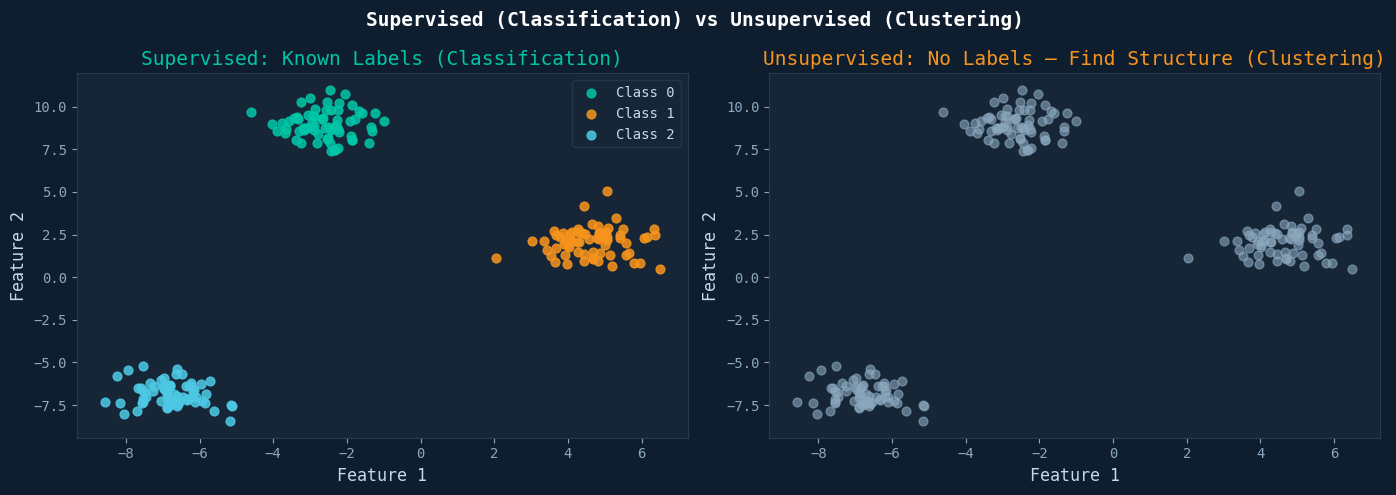

📌  In clustering we have the RIGHT plot — raw data without labels.
    Our goal is to discover the grouping shown on the LEFT by ourselves.


In [ ]:
# Visualise: Supervised vs Unsupervised
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Supervised (Classification) vs Unsupervised (Clustering)", fontsize=14, fontweight='bold', color='white')

# Left: Classification — labelled data
X_cls, y_cls = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)
for i, clr in enumerate(PALETTE[:3]):
    mask = y_cls == i
    axes[0].scatter(X_cls[mask, 0], X_cls[mask, 1], c=clr, s=40, label=f'Class {i}', alpha=0.85)
axes[0].set_title("Supervised: Known Labels (Classification)", color=PALETTE[0])
axes[0].legend()
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Right: Clustering — no labels, discovered structure
axes[1].scatter(X_cls[:, 0], X_cls[:, 1], c='#8BA8BE', s=40, alpha=0.6)
axes[1].set_title("Unsupervised: No Labels — Find Structure (Clustering)", color=PALETTE[1])
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.savefig('supervised_vs_unsupervised.png', dpi=120, bbox_inches='tight')
plt.show()
print("📌  In clustering we have the RIGHT plot — raw data without labels.")
print("    Our goal is to discover the grouping shown on the LEFT by ourselves.")


---
# PART 2 — K-Means Clustering

## 📖 2.1 The Algorithm — Step by Step

**K-Means** partitions n data points into K non-overlapping clusters by minimising the **Within-Cluster Sum of Squares (WCSS)**:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

Where:
- $K$ = number of clusters (hyperparameter set by user)
- $C_k$ = set of points assigned to cluster $k$  
- $\mu_k$ = centroid (mean) of cluster $k$

---

### 🔄 Algorithm Steps

```
Step 1 — INITIALISE
    Randomly select K data points as initial centroids.
    (k-means++ uses a smarter initialisation to avoid bad starts)

Step 2 — ASSIGN
    For every data point, compute its distance to all K centroids.
    Assign each point to its nearest centroid.
    distance(x, μ) = √Σ(xᵢ − μᵢ)²   ← Euclidean distance

Step 3 — UPDATE
    Recompute each centroid as the mean of all points assigned to it:
    μₖ = (1/|Cₖ|) Σ xᵢ   for all xᵢ ∈ Cₖ

Step 4 — REPEAT
    Go back to Step 2.
    Stop when centroids no longer change (convergence) or max_iter reached.
```

> ⚠️ **Convergence is guaranteed** but only to a **local minimum** — that's why we run it multiple times (`n_init` parameter).


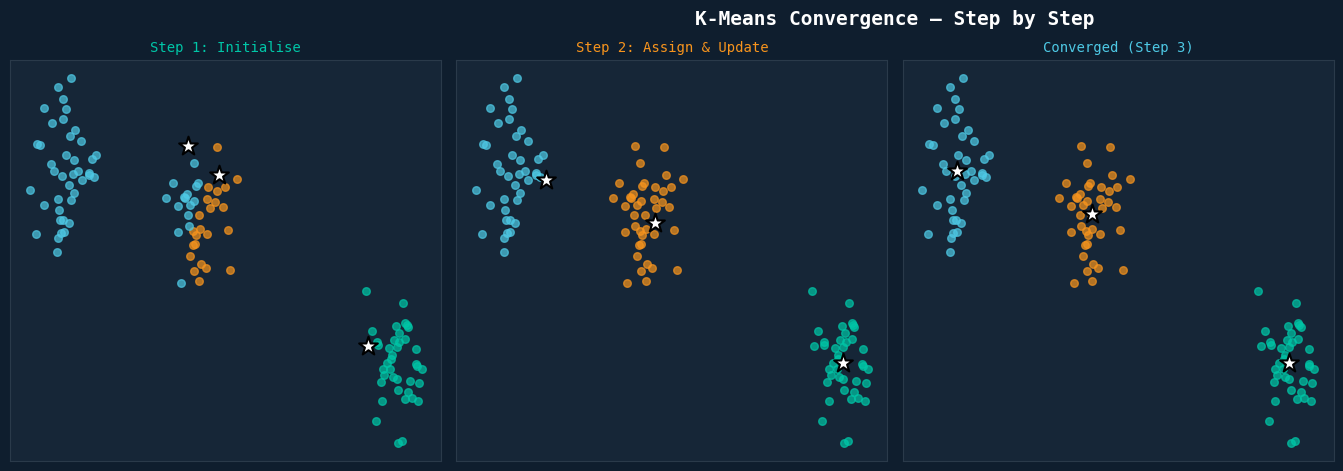

🎯  Observe how the centroids (★) move and stabilise as iterations progress.


In [73]:
# DEMO: Visualise K-Means Steps
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Generate simple 2D data
X_demo, _ = make_blobs(n_samples=120, centers=3, cluster_std=0.9, random_state=7)

def kmeans_steps(X, K=3, n_steps=6, seed=10):
    """Run K-Means manually and return intermediate states."""
    rng = np.random.RandomState(seed)
    centroids = X[rng.choice(len(X), K, replace=False)]
    history = []
    for _ in range(n_steps):
        # Assign
        dists = cdist(X, centroids)
        labels = np.argmin(dists, axis=1)
        history.append((centroids.copy(), labels.copy()))
        # Update
        new_centroids = np.array([X[labels == k].mean(axis=0) if (labels==k).any()
                                  else centroids[k] for k in range(K)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return history

history = kmeans_steps(X_demo, K=3, n_steps=8)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("K-Means Convergence — Step by Step", fontsize=14, fontweight='bold', color='white')
axes = axes.flatten()

for step_idx, (centroids, labels) in enumerate(history[:8]):
    ax = axes[step_idx]
    for k in range(3):
        mask = labels == k
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
                   c=PALETTE[k], s=30, alpha=0.7, label=f'C{k}')
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='white', s=200, marker='*', zorder=5,
               edgecolors='black', linewidths=1.5, label='Centroids')
    title = "Step 1: Initialise" if step_idx == 0 else f"Step {step_idx+1}: Assign & Update"
    if step_idx == len(history)-1:
        title = f"Converged (Step {step_idx+1})"
    ax.set_title(title, fontsize=10, color=PALETTE[step_idx % len(PALETTE)])
    ax.set_xticks([]); ax.set_yticks([])

# Hide unused axes
for i in range(len(history), 8):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('kmeans_steps.png', dpi=120, bbox_inches='tight')
plt.show()
print("🎯  Observe how the centroids (★) move and stabilise as iterations progress.")


---
## 🛠️ 2.2 K-Means From Scratch (Pure NumPy)

Before using Scikit-Learn, let's build K-Means ourselves to truly understand it.


In [ ]:
# K-Means from Scratch
class KMeansScratch:
    """
    K-Means clustering implemented from scratch using NumPy.

    Parameters
    ----------
    n_clusters : int
        Number of clusters K.
    max_iter   : int
        Maximum number of E-M iterations.
    tol        : float
        Convergence tolerance — stops if centroid shift < tol.
    random_state : int
        Seed for reproducibility.
    """
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.K          = n_clusters
        self.max_iter   = max_iter
        self.tol        = tol
        self.rng        = np.random.RandomState(random_state)

    def fit(self, X):
        # ── Step 1: Initialise centroids randomly ──────────────────────────
        idx = self.rng.choice(len(X), self.K, replace=False)
        self.centroids_ = X[idx].astype(float)

        for iteration in range(self.max_iter):
            # ── Step 2: Assign each point to nearest centroid ───────────────
            labels = self._assign(X)

            # ── Step 3: Update centroids as cluster means ───────────────────
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if (labels == k).any()
                else self.centroids_[k]
                for k in range(self.K)
            ])

            # ── Step 4: Check convergence ───────────────────────────────────
            shift = np.linalg.norm(new_centroids - self.centroids_)
            self.centroids_ = new_centroids

            if shift < self.tol:
                print(f"   ✅  Converged after {iteration + 1} iterations "
                      f"(centroid shift = {shift:.6f})")
                break

        self.labels_   = self._assign(X)
        self.inertia_  = self._wcss(X)
        self.n_iter_   = iteration + 1
        return self

    def predict(self, X):
        return self._assign(X)

    def _assign(self, X):
        """Assign points to nearest centroid (vectorised)."""
        dists = cdist(X, self.centroids_, metric='euclidean')  # (n, K)
        return np.argmin(dists, axis=1)

    def _wcss(self, X):
        """Compute Within-Cluster Sum of Squares."""
        total = 0.0
        for k in range(self.K):
            pts = X[self.labels_ == k]
            if len(pts) > 0:
                total += np.sum((pts - self.centroids_[k])**2)
        return total

# Test on synthetic data
X_test, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

print("Running KMeans from Scratch...")
km_scratch = KMeansScratch(n_clusters=4, random_state=42)
km_scratch.fit(X_scaled)

print(f"   WCSS (Inertia) : {km_scratch.inertia_:.4f}")
print(f"   Cluster sizes  : {[int((km_scratch.labels_==k).sum()) for k in range(4)]}")


Running KMeans from Scratch...
   ✅  Converged after 5 iterations (centroid shift = 0.000000)
   WCSS (Inertia) : 65.5669
   Cluster sizes  : [44, 75, 31, 150]


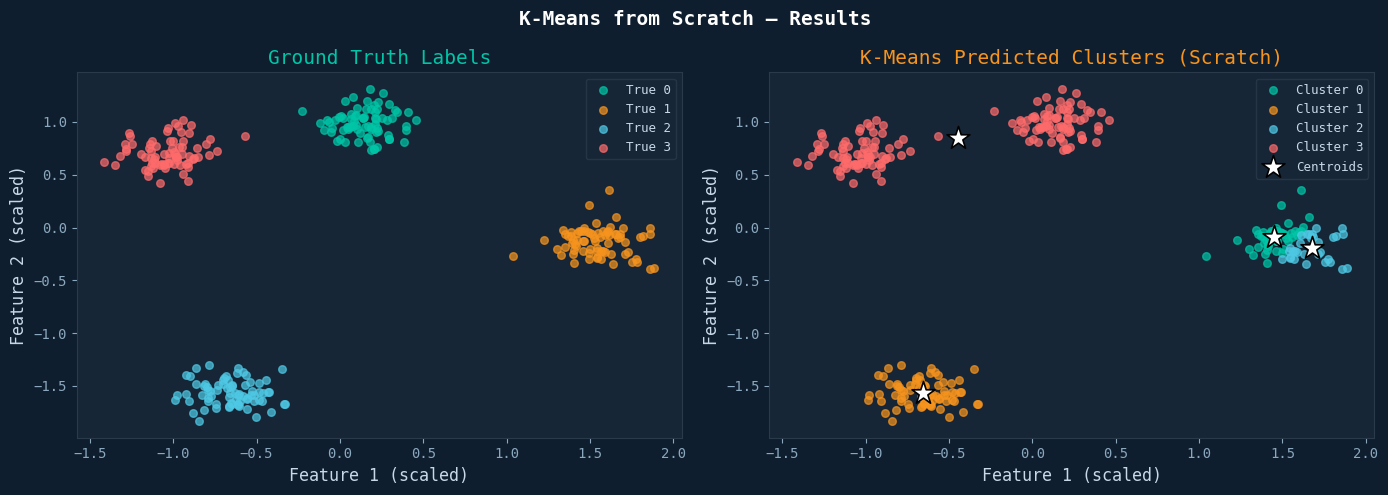

✅  Our scratch implementation correctly identified all 4 clusters!
    (Minor colour mismatches are expected — cluster IDs are arbitrary)


In [ ]:
# Plot the scratch result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means from Scratch — Results", fontsize=14, fontweight='bold', color='white')

# Ground truth
for k in range(4):
    mask = y_true == k
    axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=PALETTE[k], s=30, alpha=0.7, label=f'True {k}')
axes[0].set_title("Ground Truth Labels", color=PALETTE[0])
axes[0].legend(fontsize=9)

# Predicted clusters
for k in range(4):
    mask = km_scratch.labels_ == k
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    c=PALETTE[k], s=30, alpha=0.7, label=f'Cluster {k}')
axes[1].scatter(km_scratch.centroids_[:, 0], km_scratch.centroids_[:, 1],
                c='white', marker='*', s=300, zorder=5,
                edgecolors='black', linewidths=1.2, label='Centroids')
axes[1].set_title("K-Means Predicted Clusters (Scratch)", color=PALETTE[1])
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("Feature 1 (scaled)")
    ax.set_ylabel("Feature 2 (scaled)")

plt.tight_layout()
plt.savefig('kmeans_scratch.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅  Our scratch implementation correctly identified all 4 clusters!")
print("    (Minor colour mismatches are expected — cluster IDs are arbitrary)")


---
## 🔬 2.3 **K-Means with Scikit-Learn**

Now let's use the production-ready `sklearn.cluster.KMeans` which adds:
- **k-means++ initialisation** (smarter, avoids bad local minima)
- **Multiple restarts** via `n_init`
- **Vectorised C implementation** (much faster)

### Key Parameters

| Parameter | Default | What it does |
|-----------|---------|--------------|
| `n_clusters` | 8 | Number of clusters K |
| `init` | `'k-means++'` | Initialisation strategy |
| `n_init` | 10 | Number of runs with different seeds |
| `max_iter` | 300 | Max iterations per run |
| `random_state` | None | Seed for reproducibility |
| `algorithm` | `'lloyd'` | `'lloyd'` (standard) or `'elkan'` (faster for dense data) |


In [ ]:
# Scikit-Learn K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters   = 4,
    init         = 'k-means++',   # smarter initialisation
    n_init       = 10,             # run 10 times, keep best
    max_iter     = 300,
    random_state = 42
)

labels_sk = kmeans.fit_predict(X_scaled)

print("─" * 50)
print("  Scikit-Learn KMeans Results")
print("─" * 50)
print(f"  n_clusters      : {kmeans.n_clusters}")
print(f"  Inertia (WCSS)  : {kmeans.inertia_:.4f}")
print(f"  Iterations      : {kmeans.n_iter_}")
print(f"  Cluster sizes   : {[int((labels_sk==k).sum()) for k in range(4)]}")
print(f"  Centroid shape  : {kmeans.cluster_centers_.shape}  → (K, n_features)")

# Compare with scratch
print(f"\n  Scratch WCSS    : {km_scratch.inertia_:.4f}")
print(f"  sklearn WCSS    : {kmeans.inertia_:.4f}")
print("  (sklearn is better because k-means++ gives smarter initialisation)")


──────────────────────────────────────────────────
  Scikit-Learn KMeans Results
──────────────────────────────────────────────────
  n_clusters      : 4
  Inertia (WCSS)  : 11.3170
  Iterations      : 2
  Cluster sizes   : [75, 75, 75, 75]
  Centroid shape  : (4, 2)  → (K, n_features)

  Scratch WCSS    : 65.5669
  sklearn WCSS    : 11.3170
  (sklearn is better because k-means++ gives smarter initialisation)


---
## 📐 2.4 Choosing K — The Elbow Method

The biggest challenge in K-Means is choosing K. The **Elbow Method** helps:

1. Run K-Means for K = 1, 2, 3, ..., n
2. Record WCSS (inertia) for each K
3. Plot K vs WCSS
4. The **"elbow"** — where WCSS drop flattens — is the optimal K

> 💡 **Intuition:** Adding more clusters always reduces WCSS. But beyond the true K, the improvement becomes marginal. The elbow is where we get the best bang for our buck.


Computing K-Means for K = 1 to 11 ...
   K= 1  Inertia = 600.00
   K= 2  Inertia = 312.73
   K= 3  Inertia = 66.70
   K= 4  Inertia = 11.32
   K= 5  Inertia = 10.13
   K= 6  Inertia = 9.00
   K= 7  Inertia = 7.89
   K= 8  Inertia = 7.03
   K= 9  Inertia = 6.36
   K=10  Inertia = 5.72
   K=11  Inertia = 5.12


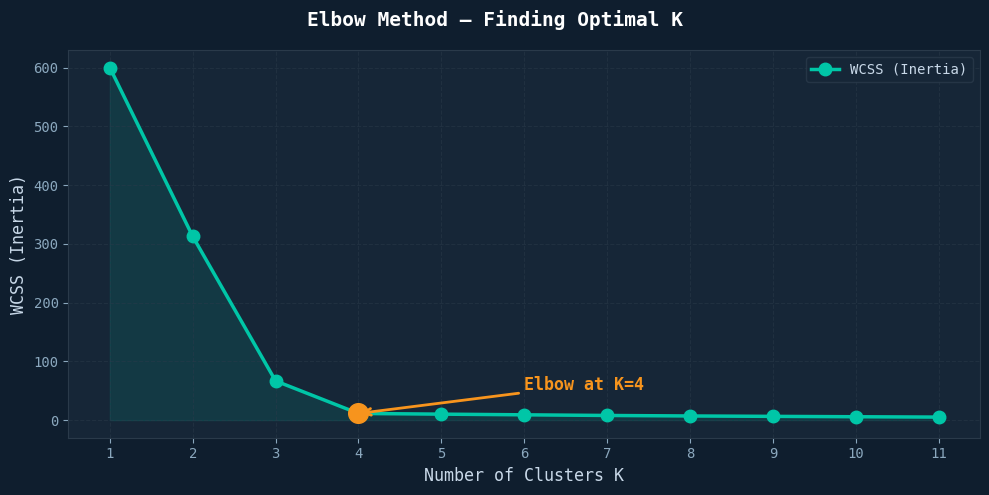


📌  The elbow is at K=4 — matching our true number of clusters.


In [ ]:
# Elbow Method
inertias = []
K_range  = range(1, 12)

print("Computing K-Means for K = 1 to 11 ...")
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"   K={k:2d}  Inertia = {km.inertia_:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Elbow Method — Finding Optimal K", fontsize=14, fontweight='bold', color='white')

ax.plot(list(K_range), inertias, marker='o', color=PALETTE[0],
        linewidth=2.5, markersize=9, label='WCSS (Inertia)')
ax.fill_between(list(K_range), inertias, alpha=0.12, color=PALETTE[0])

# Annotate the elbow at K=4
ax.annotate("Elbow at K=4", xy=(4, inertias[3]),
            xytext=(6, inertias[3] + 40),
            arrowprops=dict(arrowstyle='->', color=PALETTE[1], lw=2),
            color=PALETTE[1], fontsize=12, fontweight='bold')
ax.scatter([4], [inertias[3]], s=200, c=PALETTE[1], zorder=5)

ax.set_xlabel("Number of Clusters K")
ax.set_ylabel("WCSS (Inertia)")
ax.set_xticks(list(K_range))
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📌  The elbow is at K=4 — matching our true number of clusters.")




---



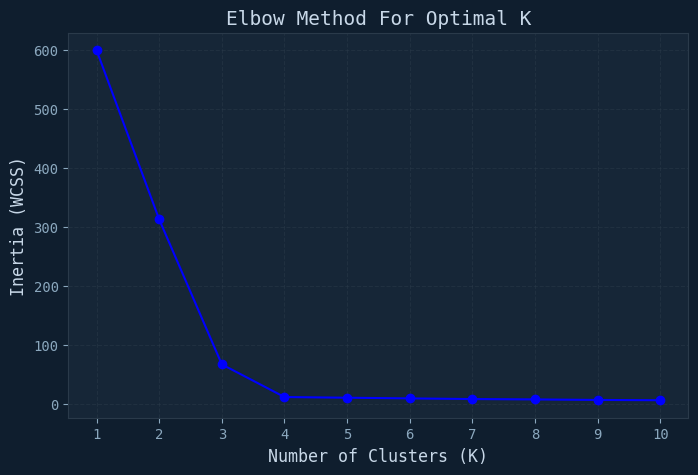

In [74]:
# 1. import
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 2. Calculate inertia for different values of K
inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init='auto' suppresses a common Future Warning in recent sklearn versions
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

---
## 📊 2.5 Silhouette Score — Validating the Clusters

The Silhouette Score provides a **quantitative measure** of clustering quality:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

Where:
- $a(i)$ = mean distance from point $i$ to **all other points in its cluster** (cohesion)
- $b(i)$ = mean distance from point $i$ to **all points in the nearest OTHER cluster** (separation)

| Score | Interpretation |
|-------|----------------|
| +1.0  | Perfect — dense, well-separated clusters |
| 0.0   | On the boundary between two clusters |
| −1.0  | Misclassified — should be in the other cluster |


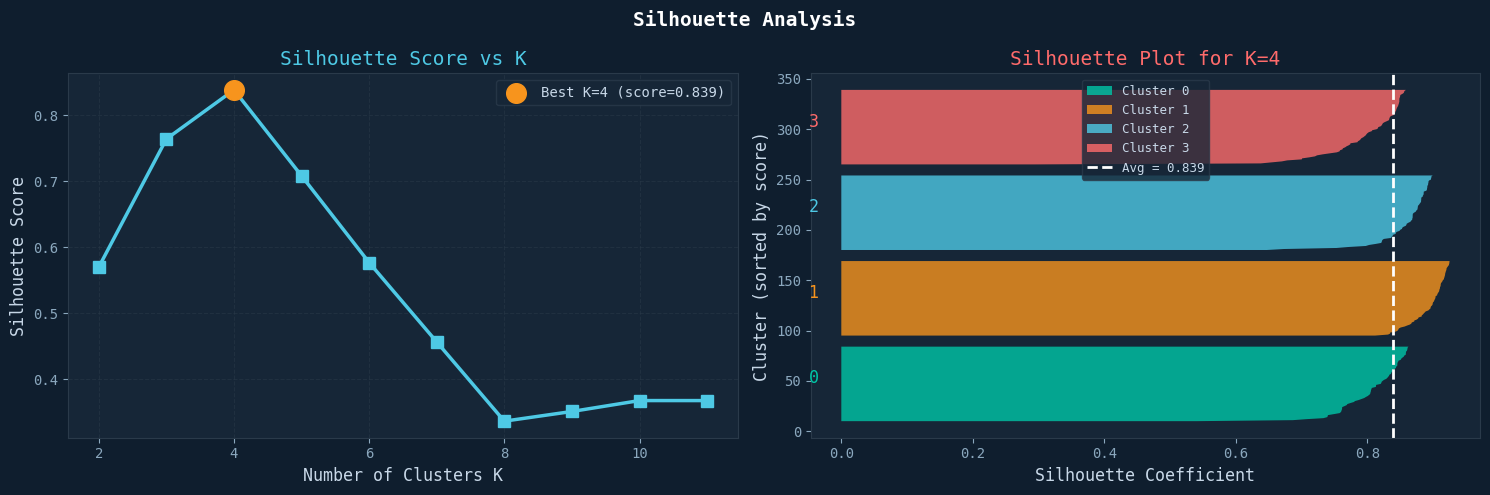

✅  Silhouette Score for K=4: 0.8386
    Wide, uniform bars = well-defined clusters.
    Thin bars below average line = points near a boundary.


In [ ]:
# Silhouette Score vs K
sil_scores = []

for k in range(2, 12):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbl)
    sil_scores.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Silhouette Analysis", fontsize=14, fontweight='bold', color='white')

# Left: Score vs K
k_vals = list(range(2, 12))
axes[0].plot(k_vals, sil_scores, marker='s', color=PALETTE[2], linewidth=2.5, markersize=9)
axes[0].scatter([4], [sil_scores[2]], s=200, c=PALETTE[1], zorder=5,
                label=f'Best K=4 (score={sil_scores[2]:.3f})')
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs K", color=PALETTE[2])
axes[0].legend()
axes[0].grid(True)

# Right: Silhouette plot for K=4
km4 = KMeans(n_clusters=4, n_init=10, random_state=42)
lbl4 = km4.fit_predict(X_scaled)
sample_sil = silhouette_samples(X_scaled, lbl4)

y_lower = 10
for k in range(4):
    sil_k = np.sort(sample_sil[lbl4 == k])
    size_k = sil_k.shape[0]
    y_upper = y_lower + size_k
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                          facecolor=PALETTE[k], alpha=0.8, label=f'Cluster {k}')
    axes[1].text(-0.05, y_lower + 0.5 * size_k, str(k), color=PALETTE[k], fontsize=12)
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, lbl4)
axes[1].axvline(x=avg_score, color='white', linestyle='--', lw=2,
                label=f'Avg = {avg_score:.3f}')
axes[1].set_xlabel("Silhouette Coefficient")
axes[1].set_ylabel("Cluster (sorted by score)")
axes[1].set_title("Silhouette Plot for K=4", color=PALETTE[3])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✅  Silhouette Score for K=4: {avg_score:.4f}")
print("    Wide, uniform bars = well-defined clusters.")
print("    Thin bars below average line = points near a boundary.")




---



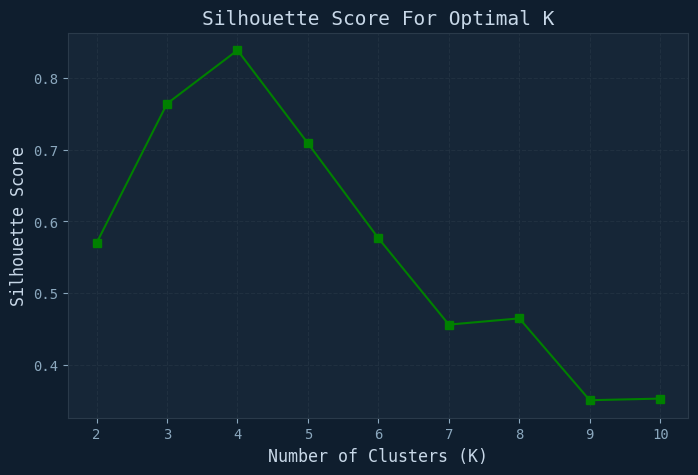

In [77]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# Calculate Silhouette Scores for different values of K
silhouette_scores = []
# Note: Silhouette score requires at least 2 clusters, so range starts at 2
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Calculate the mean silhouette coefficient for all samples
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True)
plt.show()

---
## 🛍️ 2.6 Real Dataset: Mall Customer Segmentation

Let's apply K-Means on a real-world retail dataset — a classic use case!

**Dataset:** Mall Customer Segmentation  
**Features:** Annual Income (k$), Spending Score (1–100)  
**Goal:** Identify customer groups for targeted marketing


In [ ]:
# ── Mall Customer Data (recreated — identical structure) ──────────────────
# Realistic synthetic version with the same clusters as the famous mall dataset
np.random.seed(42)

# 5 natural clusters: low-income-low-spend, low-income-high-spend,
#                     mid-income-mid-spend, high-income-low-spend, high-income-high-spend
centres = [(25, 20), (25, 78), (55, 50), (85, 18), (85, 82)]
cov     = [[35, 0], [0, 60]]

rows = []
for (mi, ms) in centres:
    n = np.random.randint(35, 50)
    pts = np.random.multivariate_normal([mi, ms], cov, n)
    for p in pts:
        rows.append({
            'CustomerID':    len(rows) + 1,
            'Gender':        np.random.choice(['Male', 'Female']),
            'Age':           int(np.clip(np.random.normal(38, 12), 18, 70)),
            'Annual Income (k$)':   float(np.clip(p[0], 10, 120)),
            'Spending Score (1-100)': float(np.clip(p[1], 1, 100)),
        })

df = pd.DataFrame(rows).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,48,28.049343,15.737902
1,2,Male,38,33.095860,23.670510
2,3,Male,55,24.265535,12.898290
3,4,Female,31,22.084536,4.423148
4,5,Male,35,19.502869,23.040910


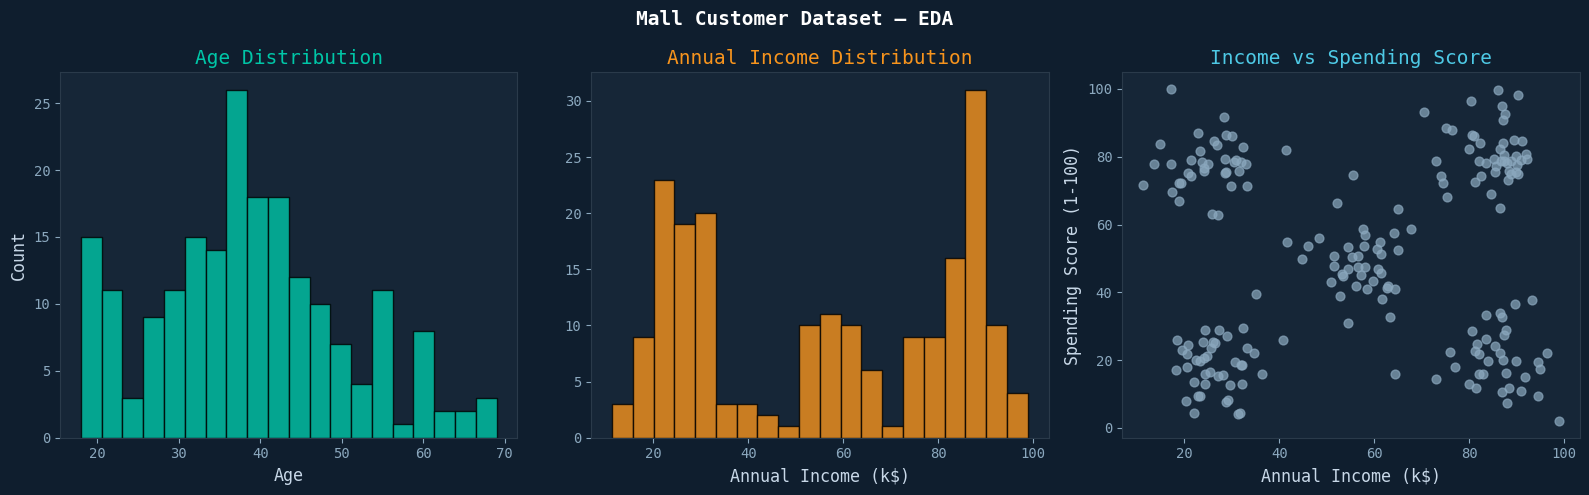


📊  Dataset stats:
       Annual Income (k$)  Spending Score (1-100)
count              200.00                  200.00
mean                56.12                   50.08
std                 27.17                   28.20
min                 11.29                    2.02
25%                 28.59                   22.12
50%                 57.70                   50.55
75%                 84.04                   77.76
max                 98.86                  100.00


In [ ]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Mall Customer Dataset — EDA", fontsize=14, fontweight='bold', color='white')

# Age distribution
axes[0].hist(df['Age'], bins=20, color=PALETTE[0], edgecolor='black', alpha=0.8)
axes[0].set_title("Age Distribution", color=PALETTE[0])
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")

# Income distribution
axes[1].hist(df['Annual Income (k$)'], bins=20, color=PALETTE[1], edgecolor='black', alpha=0.8)
axes[1].set_title("Annual Income Distribution", color=PALETTE[1])
axes[1].set_xlabel("Annual Income (k$)")

# Income vs Spending Score (raw)
axes[2].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                c='#8BA8BE', s=40, alpha=0.7)
axes[2].set_title("Income vs Spending Score", color=PALETTE[2])
axes[2].set_xlabel("Annual Income (k$)")
axes[2].set_ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📊  Dataset stats:")
print(df[['Annual Income (k$)', 'Spending Score (1-100)']].describe().round(2))


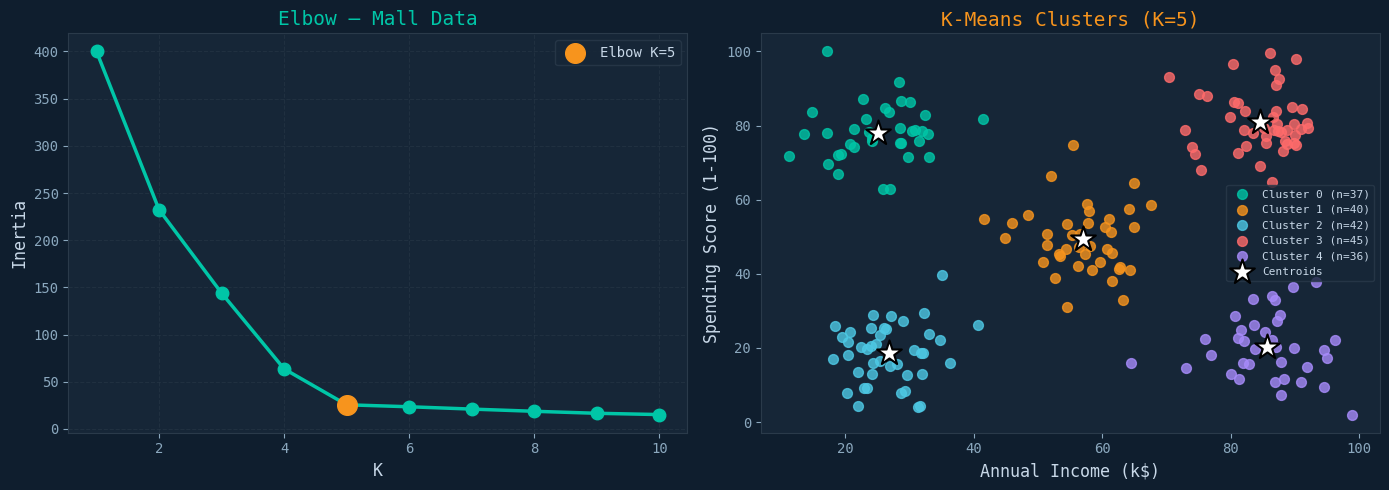


📋  Cluster Profiles:
         Annual Income (k$)  Spending Score (1-100)   Age
Cluster                                                  
0                      25.1                    78.0  35.8
1                      57.0                    49.4  40.4
2                      26.8                    18.6  39.3
3                      84.6                    81.0  39.0
4                      85.7                    20.3  37.9


In [ ]:
# ── Apply K-Means to Mall Customers ──────────────────────────────────────
X_mall = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler_mall = StandardScaler()
X_mall_sc   = scaler_mall.fit_transform(X_mall)

# Elbow for mall data
inertias_mall = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_mall_sc).inertia_
                 for k in range(1, 11)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(range(1,11), inertias_mall, marker='o', color=PALETTE[0], linewidth=2.5, markersize=9)
axes[0].scatter([5], [inertias_mall[4]], s=200, c=PALETTE[1], zorder=5, label='Elbow K=5')
axes[0].set_title("Elbow — Mall Data", color=PALETTE[0])
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[0].legend(); axes[0].grid(True)

# Final clustering K=5
km_mall = KMeans(n_clusters=5, n_init=10, random_state=42)
mall_labels = km_mall.fit_predict(X_mall_sc)
centres_orig = scaler_mall.inverse_transform(km_mall.cluster_centers_)

cluster_names = {
    0: "💰 High Income High Spend",
    1: "🎯 Mid Income Mid Spend",
    2: "💸 Low Income High Spend",
    3: "📈 High Income Low Spend",
    4: "🏠 Low Income Low Spend"
}

for k in range(5):
    mask = mall_labels == k
    axes[1].scatter(X_mall[mask, 0], X_mall[mask, 1],
                    c=PALETTE[k], s=50, alpha=0.8,
                    label=f'Cluster {k} (n={mask.sum()})')
axes[1].scatter(centres_orig[:, 0], centres_orig[:, 1],
                c='white', marker='*', s=350, zorder=5,
                edgecolors='black', lw=1.5, label='Centroids')
axes[1].set_title("K-Means Clusters (K=5)", color=PALETTE[1])
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('mall_kmeans.png', dpi=120, bbox_inches='tight')
plt.show()

# Print cluster profile
print("\n📋  Cluster Profiles:")
df['Cluster'] = mall_labels
print(df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)','Age']].mean().round(1))




---





---



---
# PART 3 — Hierarchical Clustering

## 📖 3.1 The Algorithm

**Hierarchical Clustering** builds a **tree of clusters (dendrogram)** — it does **not** require you to specify K in advance.

### Two Strategies

| Strategy | Direction | How it works |
|----------|-----------|--------------|
| **Agglomerative** | Bottom-Up ↑ | Start: each point = its own cluster. Merge closest pair repeatedly. |
| **Divisive** | Top-Down ↓ | Start: all points in one cluster. Recursively split. |

> Agglomerative is by far the more common approach and what Scikit-Learn implements.

---

### Linkage Criteria — How do we measure "distance between clusters"?

| Linkage | Formula | Behaviour |
|---------|---------|-----------|
| **Single** | min distance between any two points | Chaining — long, thin clusters |
| **Complete** | max distance between any two points | Compact, roughly equal-size clusters |
| **Average** | mean distance between all pairs | Balanced |
| **Ward** | minimise increase in total WCSS | Usually best — produces even clusters |

---

### Algorithmic Complexity

- Time:   **O(n² log n)** — quadratic!
- Memory: **O(n²)** — stores full distance matrix

> 💡 This is why Hierarchical Clustering is best for **smaller datasets (< 10k points)**.


---
## 🌳 3.2 Dendrogram — Understanding and Plotting

A **dendrogram** is a tree diagram that shows:
- The **order** in which clusters were merged
- The **distance (height)** at which each merge occurred

> 🔑 To get K clusters, draw a **horizontal cut** across the dendrogram at the appropriate height.


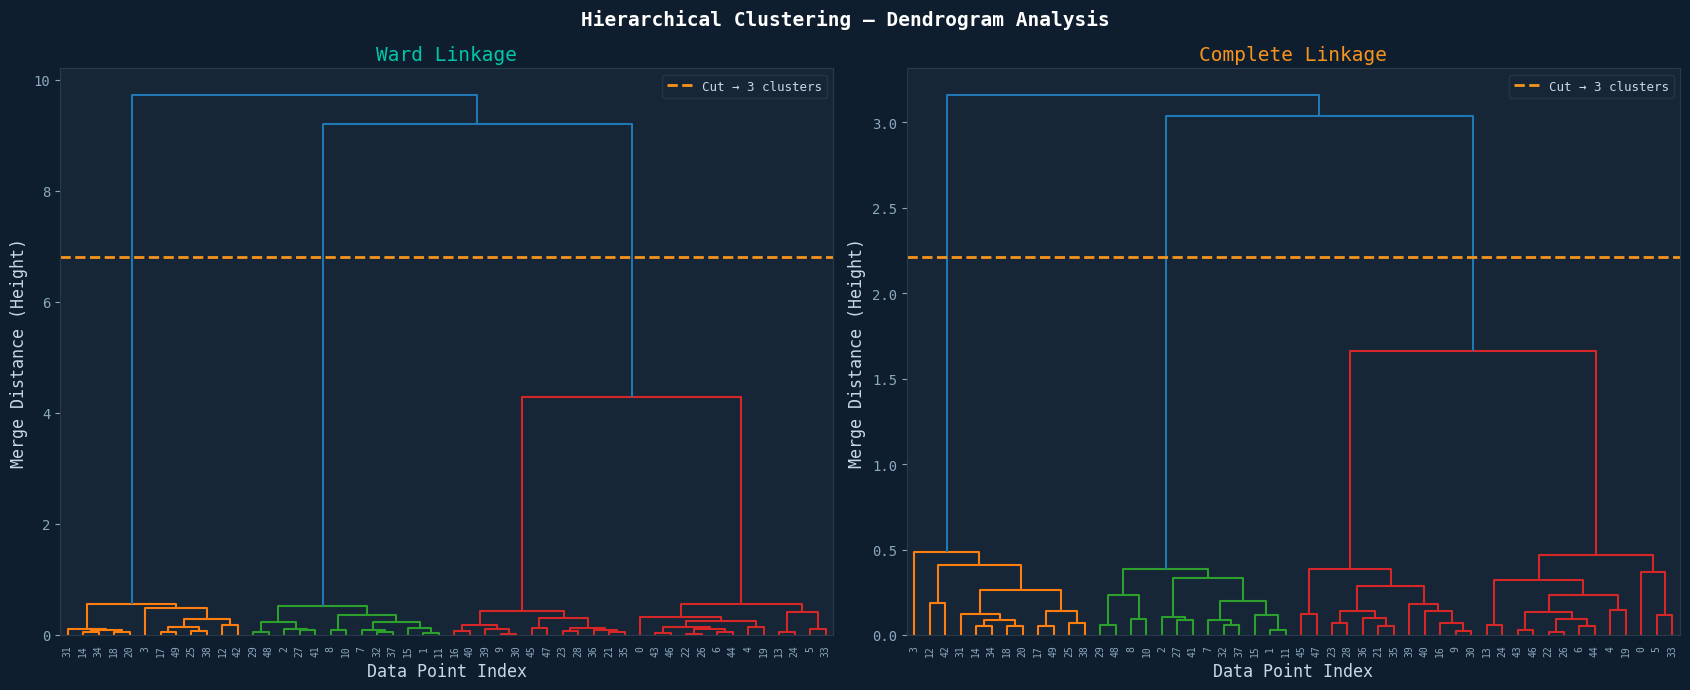

📌  How to read a dendrogram:
    • Horizontal axis = data points (leaves)
    • Vertical axis   = distance at which clusters were merged
    • Higher merge    = clusters that are more dissimilar
    • Draw a horizontal cut → count the vertical lines crossed = K clusters


In [ ]:
# Dendrogram Visualisation
# Use a small dataset so the dendrogram is legible
X_hier, _ = make_blobs(n_samples=50, centers=4, cluster_std=0.7, random_state=42)
X_hier_sc  = StandardScaler().fit_transform(X_hier)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle("Hierarchical Clustering — Dendrogram Analysis", fontsize=14, fontweight='bold', color='white')

linkage_methods = ['ward', 'complete']
titles          = ['Ward Linkage', 'Complete Linkage']

for ax, method, title in zip(axes, linkage_methods, titles):
    Z = linkage(X_hier_sc, method=method)
    dn = dendrogram(
        Z,
        ax              = ax,
        leaf_rotation   = 90,
        leaf_font_size  = 7,
        color_threshold = 0.7 * max(Z[:, 2]),
    )
    # Draw cut line
    cut_height = 0.7 * max(Z[:, 2])
    ax.axhline(y=cut_height, color=PALETTE[1], linestyle='--', lw=2,
               label=f'Cut → {len(set(fcluster(Z, t=cut_height, criterion="distance")))} clusters')
    ax.set_title(title, color=PALETTE[0] if method=='ward' else PALETTE[1])
    ax.set_xlabel("Data Point Index")
    ax.set_ylabel("Merge Distance (Height)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

print("📌  How to read a dendrogram:")
print("    • Horizontal axis = data points (leaves)")
print("    • Vertical axis   = distance at which clusters were merged")
print("    • Higher merge    = clusters that are more dissimilar")
print("    • Draw a horizontal cut → count the vertical lines crossed = K clusters")


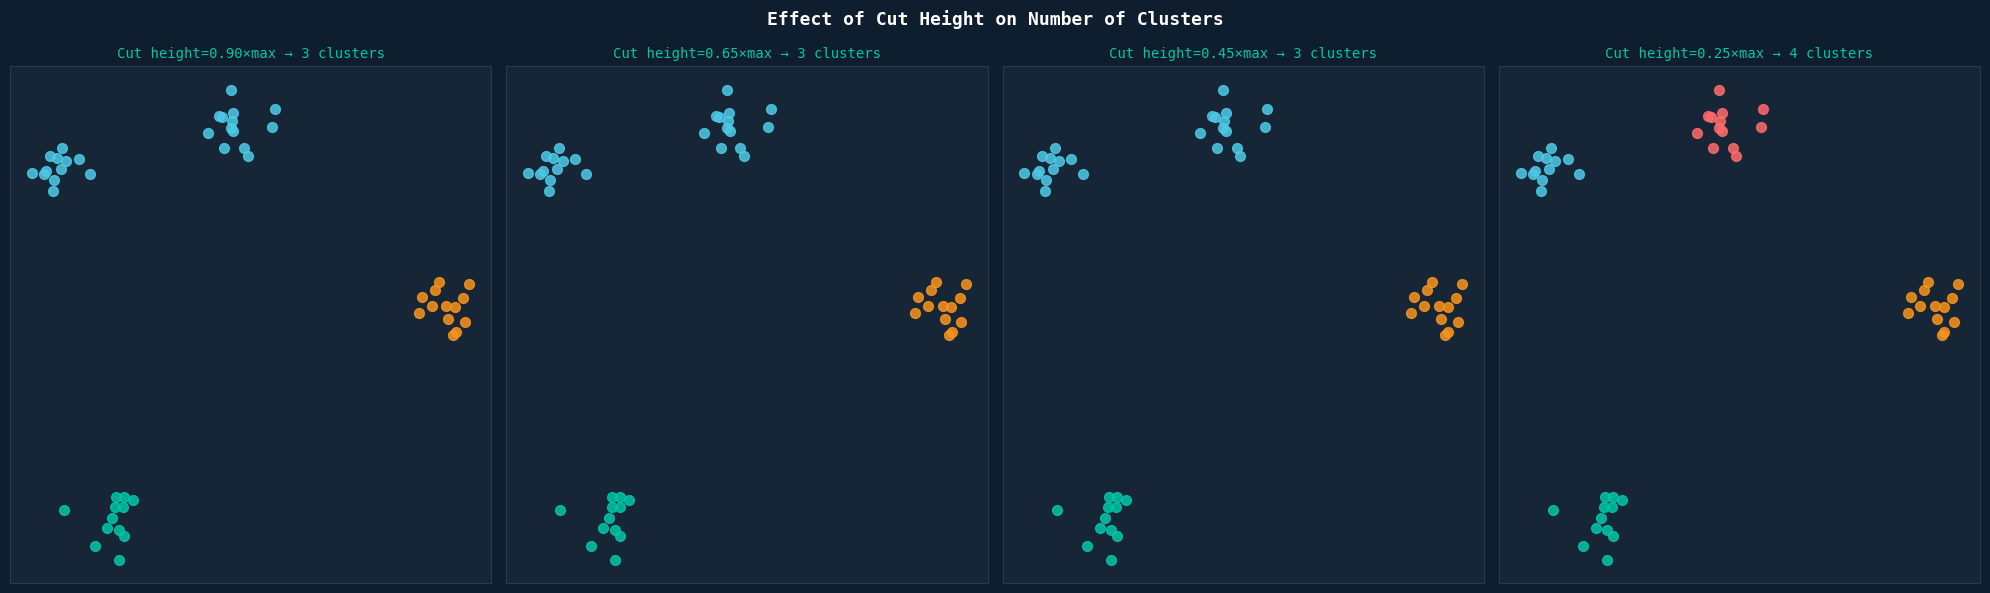

🎯  The cut height is the key hyperparameter in hierarchical clustering.
    It directly controls how many clusters you extract from the dendrogram.


In [ ]:
# Show how cut height determines number of clusters
Z_ward = linkage(X_hier_sc, method='ward')

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Effect of Cut Height on Number of Clusters", fontsize=13, fontweight='bold', color='white')

cut_heights = [0.9, 0.65, 0.45, 0.25]
K_list      = [2,   3,    4,    6  ]

for ax, cut_frac, K_exp in zip(axes, cut_heights, K_list):
    cut_h  = cut_frac * max(Z_ward[:, 2])
    labels = fcluster(Z_ward, t=cut_h, criterion='distance') - 1
    n_clust = len(np.unique(labels))

    for k in range(n_clust):
        mask = labels == k
        ax.scatter(X_hier_sc[mask, 0], X_hier_sc[mask, 1],
                   c=PALETTE[k % len(PALETTE)], s=50, alpha=0.85)
    ax.set_title(f"Cut height={cut_frac:.2f}×max → {n_clust} clusters",
                 color=PALETTE[0], fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('cut_heights.png', dpi=120, bbox_inches='tight')
plt.show()
print("🎯  The cut height is the key hyperparameter in hierarchical clustering.")
print("    It directly controls how many clusters you extract from the dendrogram.")


---
## 🔬 3.3 Agglomerative Clustering with Scikit-Learn

### Key Parameters

| Parameter | Default | What it does |
|-----------|---------|--------------|
| `n_clusters` | 2 | How many clusters to extract |
| `linkage` | `'ward'` | Linkage criterion: `ward`, `complete`, `average`, `single` |
| `metric` | `'euclidean'` | Distance metric (use with non-ward linkages) |
| `compute_full_tree` | `'auto'` | Whether to compute the full dendrogram |


In [ ]:
# Agglomerative Clustering with Scikit-Learn ───────────────────────────
from sklearn.cluster import AgglomerativeClustering

X_full, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X_full_sc  = StandardScaler().fit_transform(X_full)

model = AgglomerativeClustering(
    n_clusters = 4,
    linkage    = 'ward',       # ward | complete | average | single
    metric     = 'euclidean'
)
labels_hier = model.fit_predict(X_full_sc)

print("─" * 50)
print("  AgglomerativeClustering Results")
print("─" * 50)
print(f"  n_clusters   : {model.n_clusters_}")
print(f"  n_leaves     : {model.n_leaves_}  (data points)")
print(f"  n_components : {model.n_connected_components_}")
print(f"  Cluster sizes: {[int((labels_hier==k).sum()) for k in range(4)]}")

# Evaluation
sil   = silhouette_score(X_full_sc, labels_hier)
ch    = calinski_harabasz_score(X_full_sc, labels_hier)
db    = davies_bouldin_score(X_full_sc, labels_hier)

print(f"\n  Silhouette Score    : {sil:.4f}  (higher = better, max 1.0)")
print(f"  Calinski-Harabász   : {ch:.2f}   (higher = better)")
print(f"  Davies-Bouldin      : {db:.4f}  (lower  = better)")


──────────────────────────────────────────────────
  AgglomerativeClustering Results
──────────────────────────────────────────────────
  n_clusters   : 4
  n_leaves     : 300  (data points)
  n_components : 1
  Cluster sizes: [75, 75, 75, 75]

  Silhouette Score    : 0.8386  (higher = better, max 1.0)
  Calinski-Harabász   : 5132.39   (higher = better)
  Davies-Bouldin      : 0.2244  (lower  = better)


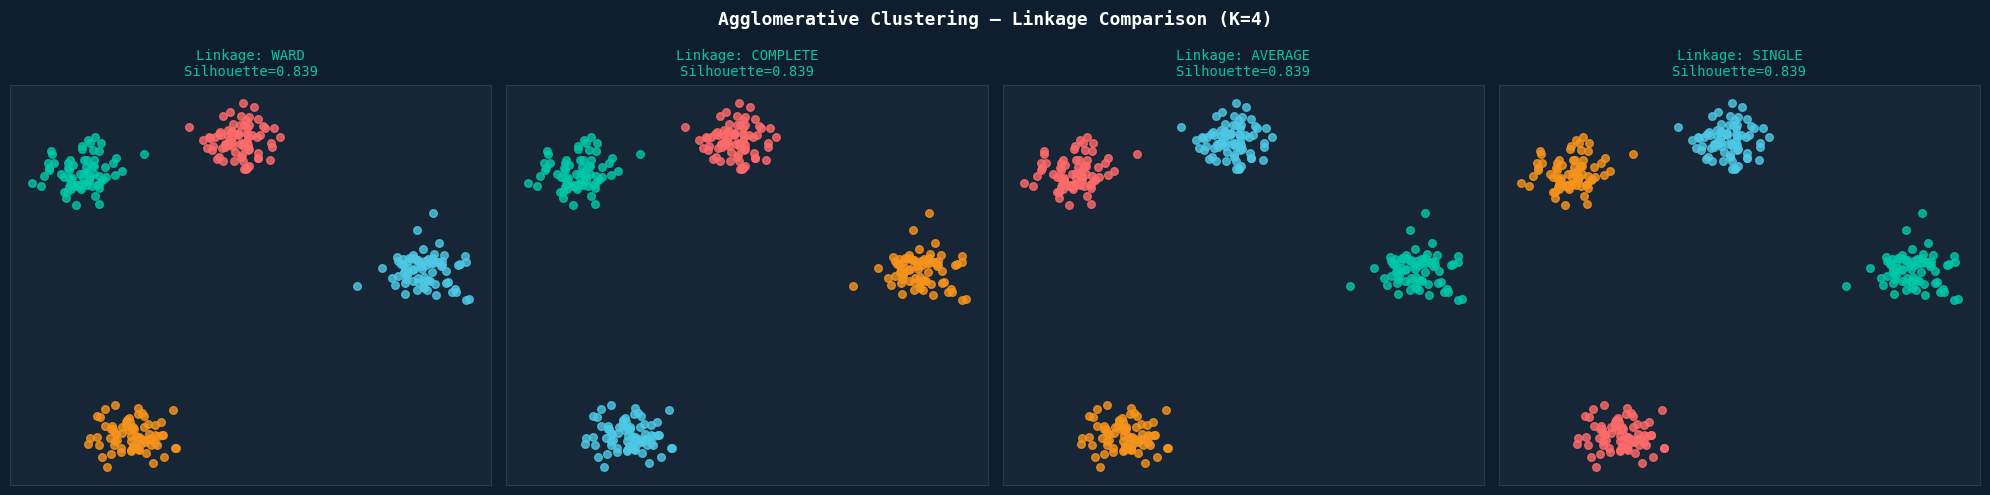

📌  Ward linkage usually gives the most compact, equal-sized clusters.
    Single linkage is prone to 'chaining' — avoid it unless needed.


In [ ]:
# ── Compare all 4 linkage methods visually ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Agglomerative Clustering — Linkage Comparison (K=4)", fontsize=13, fontweight='bold', color='white')

for ax, method in zip(axes, ['ward', 'complete', 'average', 'single']):
    model_m = AgglomerativeClustering(n_clusters=4, linkage=method)
    lbl_m   = model_m.fit_predict(X_full_sc)
    sil_m   = silhouette_score(X_full_sc, lbl_m)

    for k in range(4):
        mask = lbl_m == k
        ax.scatter(X_full_sc[mask, 0], X_full_sc[mask, 1],
                   c=PALETTE[k], s=30, alpha=0.8)
    ax.set_title(f"Linkage: {method.upper()}\nSilhouette={sil_m:.3f}", fontsize=10, color=PALETTE[0])
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('linkage_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("📌  Ward linkage usually gives the most compact, equal-sized clusters.")
print("    Single linkage is prone to 'chaining' — avoid it unless needed.")


---
# PART 4 — Cluster Evaluation Metrics

Since clustering is unsupervised, we cannot use accuracy. Instead, we use **internal validation metrics** — no ground truth needed!

## 📏 The Three Main Metrics

### 1. Silhouette Score
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
- $a(i)$ = intra-cluster distance (cohesion)
- $b(i)$ = nearest-cluster distance (separation)
- **Range:** −1 to +1 | **Higher is better**

### 2. Calinski-Harabász (CH) Index
$$CH = \frac{\text{Between-cluster dispersion} / (K-1)}{\text{Within-cluster dispersion} / (n-K)}$$
- **Range:** 0 to ∞ | **Higher is better**

### 3. Davies-Bouldin Index
$$DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} \frac{\sigma_i + \sigma_j}{d(c_i, c_j)}$$
- $\sigma_k$ = average distance from cluster $k$ to its centroid
- $d(c_i, c_j)$ = distance between centroids $i$ and $j$
- **Range:** 0 to ∞ | **Lower is better**


Clustering Metrics vs K:
    Silhouette  Calinski-Harabász  Davies-Bouldin  Inertia
K                                                         
2       0.5641             362.02          0.5682   418.94
3       0.7536            1511.66          0.3592    92.86
4       0.8202            5472.33          0.2502    18.84
5       0.6872            4581.78          0.6062    16.88
6       0.5642            4134.26          0.8162    14.96
7       0.4437            3913.66          0.9852    13.17
8       0.3407            3796.54          1.0979    11.63
9       0.3544            3628.44          1.0027    10.63
10      0.3546            3569.83          0.9707     9.59


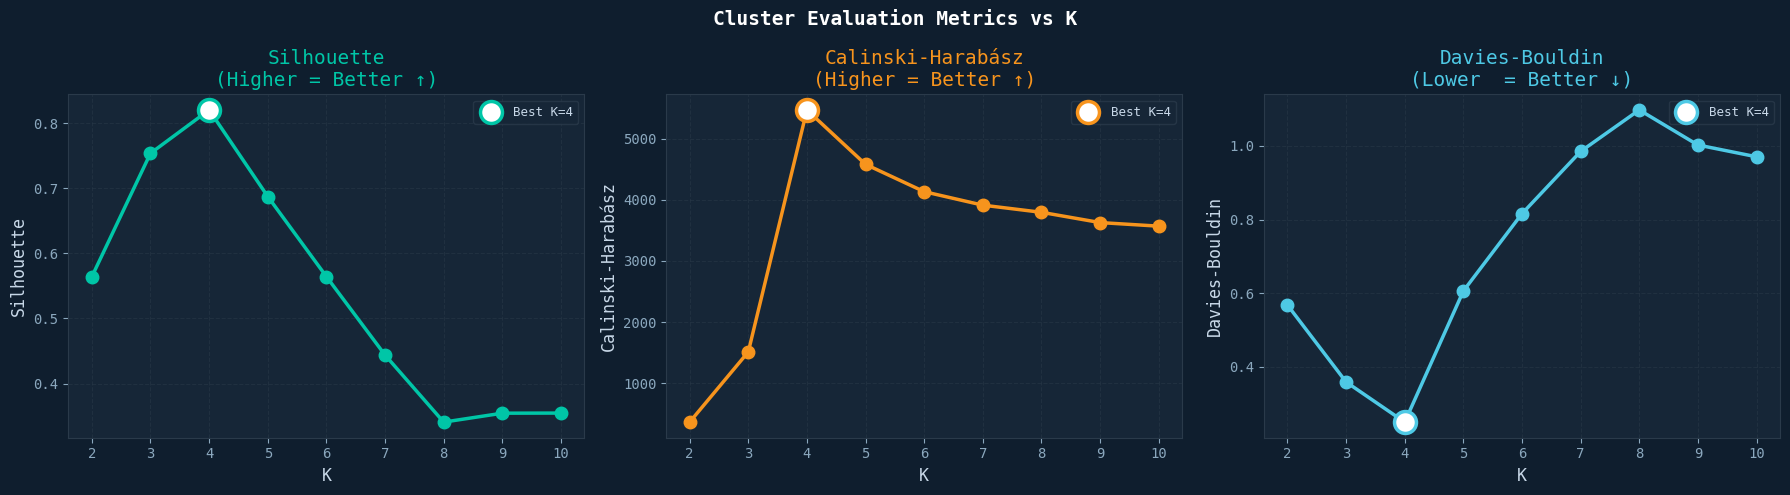

✅  All three metrics agree: K=4 is optimal for this dataset.


In [ ]:
# ── Comprehensive Metric Comparison Across K Values ──────────────────────
X_eval, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=42)
X_eval_sc  = StandardScaler().fit_transform(X_eval)

results = []
for k in range(2, 11):
    km_e  = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl_e = km_e.fit_predict(X_eval_sc)
    results.append({
        'K':         k,
        'Silhouette':           round(silhouette_score(X_eval_sc, lbl_e), 4),
        'Calinski-Harabász':    round(calinski_harabasz_score(X_eval_sc, lbl_e), 2),
        'Davies-Bouldin':       round(davies_bouldin_score(X_eval_sc, lbl_e), 4),
        'Inertia':              round(km_e.inertia_, 2),
    })

df_metrics = pd.DataFrame(results).set_index('K')
print("Clustering Metrics vs K:")
print(df_metrics.to_string())

# ── Plot all three ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cluster Evaluation Metrics vs K", fontsize=14, fontweight='bold', color='white')

metrics_cfg = [
    ('Silhouette',         PALETTE[0], 'Higher = Better ↑', True),
    ('Calinski-Harabász',  PALETTE[1], 'Higher = Better ↑', True),
    ('Davies-Bouldin',     PALETTE[2], 'Lower  = Better ↓', False),
]
for ax, (metric, clr, note, higher_better) in zip(axes, metrics_cfg):
    k_vals = df_metrics.index.tolist()
    vals   = df_metrics[metric].tolist()
    best_k = k_vals[np.argmax(vals) if higher_better else np.argmin(vals)]
    best_v = max(vals) if higher_better else min(vals)

    ax.plot(k_vals, vals, marker='o', color=clr, linewidth=2.5, markersize=9)
    ax.scatter([best_k], [best_v], s=250, c='white', zorder=5,
               edgecolors=clr, linewidths=2.5, label=f'Best K={best_k}')
    ax.set_title(f"{metric}\n({note})", color=clr)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅  All three metrics agree: K=4 is optimal for this dataset.")


---
# PART 5 — K-Means vs Hierarchical: Side-by-Side

Let's compare both algorithms on the same datasets — including datasets where one outperforms the other.


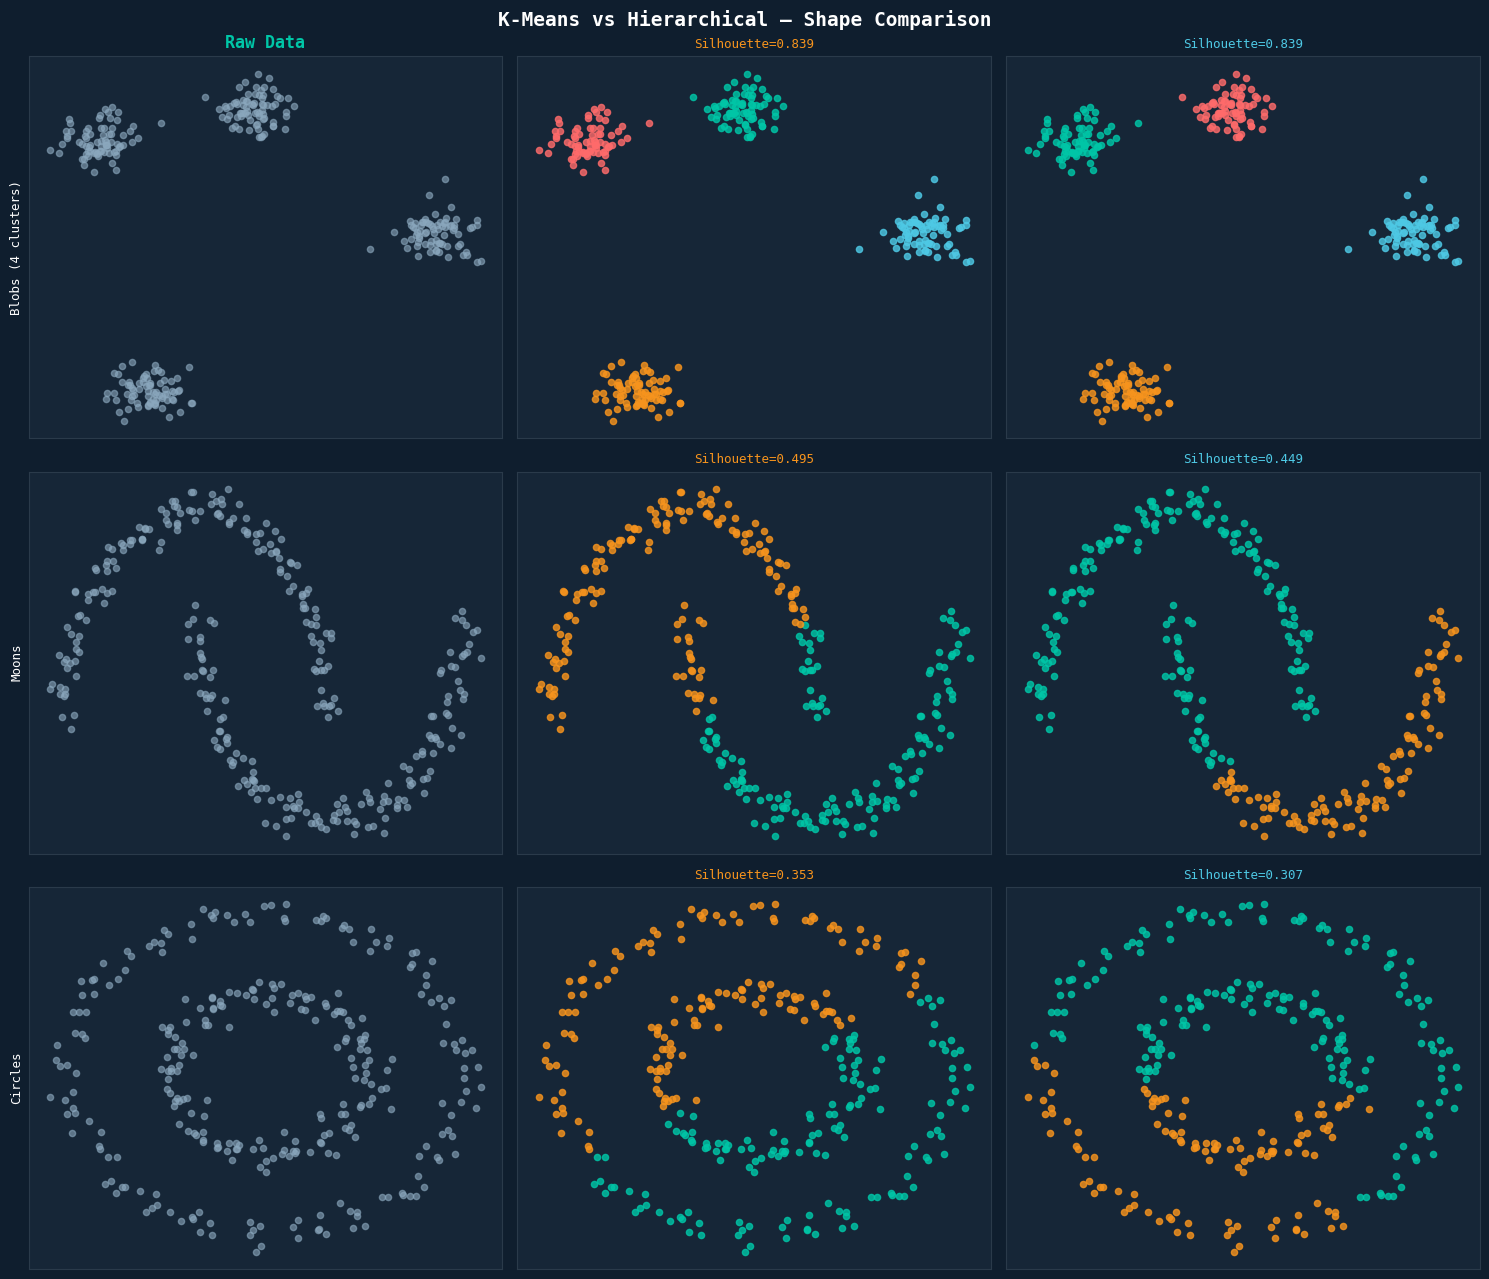

📌  Key Insight:
    Both algorithms work well on convex/blob-shaped data.
    Both FAIL on moons/circles — their shapes aren't spherical.
    For non-convex shapes → use DBSCAN or Spectral Clustering.


In [ ]:
# ── Side-by-Side Comparison on Multiple Dataset Shapes ───────────────────
datasets = {
    'Blobs (4 clusters)': make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)[0],
    'Moons':              make_moons(n_samples=300, noise=0.05, random_state=42)[0],
    'Circles':            make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0],
}
K_choices = {'Blobs (4 clusters)': 4, 'Moons': 2, 'Circles': 2}

fig, axes = plt.subplots(len(datasets), 3, figsize=(15, 13))
fig.suptitle("K-Means vs Hierarchical — Shape Comparison", fontsize=14, fontweight='bold', color='white')

col_titles = ['Raw Data', 'K-Means', 'Hierarchical (Ward)']
for j, ct in enumerate(col_titles):
    axes[0, j].set_title(ct, fontsize=12, color=PALETTE[j], fontweight='bold')

for i, (name, X_d) in enumerate(datasets.items()):
    K_d  = K_choices[name]
    X_ds = StandardScaler().fit_transform(X_d)

    # Raw
    axes[i, 0].scatter(X_ds[:, 0], X_ds[:, 1], c='#8BA8BE', s=20, alpha=0.6)
    axes[i, 0].set_ylabel(name, fontsize=9, color='white')

    # K-Means
    km_lbl = KMeans(n_clusters=K_d, n_init=10, random_state=42).fit_predict(X_ds)
    for k in range(K_d):
        axes[i, 1].scatter(X_ds[km_lbl==k, 0], X_ds[km_lbl==k, 1],
                           c=PALETTE[k], s=20, alpha=0.8)
    sil_km = silhouette_score(X_ds, km_lbl)
    axes[i, 1].set_title(f"Silhouette={sil_km:.3f}", fontsize=9, color=PALETTE[1])

    # Hierarchical
    h_lbl = AgglomerativeClustering(n_clusters=K_d, linkage='ward').fit_predict(X_ds)
    for k in range(K_d):
        axes[i, 2].scatter(X_ds[h_lbl==k, 0], X_ds[h_lbl==k, 1],
                           c=PALETTE[k], s=20, alpha=0.8)
    sil_h = silhouette_score(X_ds, h_lbl)
    axes[i, 2].set_title(f"Silhouette={sil_h:.3f}", fontsize=9, color=PALETTE[2])

    for j in range(3):
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("📌  Key Insight:")
print("    Both algorithms work well on convex/blob-shaped data.")
print("    Both FAIL on moons/circles — their shapes aren't spherical.")
print("    For non-convex shapes → use DBSCAN or Spectral Clustering.")


In [ ]:
# ── Summary Comparison Table ──────────────────────────────────────────────
comparison = {
    'Aspect': [
        'Specify K upfront?', 'Scalability', 'Cluster shape',
        'Deterministic?', 'Result type', 'Memory usage',
        'Best for', 'Linkage options', 'Typical use'
    ],
    'K-Means': [
        '✅ Required', 'O(n·K·i·d) — scales to millions', 'Convex / spherical only',
        '❌ No (random init)', 'Flat partition of K clusters', 'Low: O(K·d)',
        'Large datasets, known K', 'N/A (centroid-based)', 'Customer segmentation, compression'
    ],
    'Hierarchical (Agglomerative)': [
        '❌ Not needed', 'O(n² log n) — best for < 10k', 'Any (depends on linkage)',
        '✅ Yes', 'Dendrogram + flat if cut', 'High: O(n²)',
        'Small data, exploring hierarchy', 'Single, Complete, Average, Ward', 'Biology, document analysis'
    ]
}
df_comp = pd.DataFrame(comparison).set_index('Aspect')
print("=" * 90)
print("  K-MEANS vs HIERARCHICAL CLUSTERING — COMPARISON SUMMARY")
print("=" * 90)
for aspect, row in df_comp.iterrows():
    print(f"\n  {aspect}")
    print(f"    K-Means       : {row['K-Means']}")
    print(f"    Hierarchical  : {row['Hierarchical (Agglomerative)']}")
print("=" * 90)


  K-MEANS vs HIERARCHICAL CLUSTERING — COMPARISON SUMMARY

  Specify K upfront?
    K-Means       : ✅ Required
    Hierarchical  : ❌ Not needed

  Scalability
    K-Means       : O(n·K·i·d) — scales to millions
    Hierarchical  : O(n² log n) — best for < 10k

  Cluster shape
    K-Means       : Convex / spherical only
    Hierarchical  : Any (depends on linkage)

  Deterministic?
    K-Means       : ❌ No (random init)
    Hierarchical  : ✅ Yes

  Result type
    K-Means       : Flat partition of K clusters
    Hierarchical  : Dendrogram + flat if cut

  Memory usage
    K-Means       : Low: O(K·d)
    Hierarchical  : High: O(n²)

  Best for
    K-Means       : Large datasets, known K
    Hierarchical  : Small data, exploring hierarchy

  Linkage options
    K-Means       : N/A (centroid-based)
    Hierarchical  : Single, Complete, Average, Ward

  Typical use
    K-Means       : Customer segmentation, compression
    Hierarchical  : Biology, document analysis


---
# PART 6 — 🧪 Mini Project: Iris Flower Clustering

**Dataset:** Fisher's Iris dataset (150 samples, 4 features, 3 species)  
**Task:** Apply both algorithms without using species labels, then evaluate how well we recover the true groups.

**This is a classic benchmark** — the 3 species (Setosa, Versicolor, Virginica) form the ground truth.


In [ ]:
# ── Load and Explore Iris ─────────────────────────────────────────────────
iris        = load_iris()
X_iris      = iris.data
y_iris      = iris.target
feat_names  = iris.feature_names
class_names = iris.target_names

df_iris = pd.DataFrame(X_iris, columns=feat_names)
df_iris['species'] = [class_names[y] for y in y_iris]

print("Iris Dataset Shape:", X_iris.shape)
print("\nClass distribution:")
print(df_iris['species'].value_counts())
print("\nFeature stats:")
print(df_iris.describe().round(2))


Iris Dataset Shape: (150, 4)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Feature stats:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  


In [ ]:
# Preprocess and Apply Both Algorithms
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

scaler_iris = StandardScaler()
X_iris_sc   = scaler_iris.fit_transform(X_iris)

# Reduce to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_iris_sc)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# K-Means
km_iris     = KMeans(n_clusters=3, n_init=20, random_state=42)
labels_km   = km_iris.fit_predict(X_iris_sc)

# Hierarchical
hc_iris     = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc   = hc_iris.fit_predict(X_iris_sc)

# ── Metrics ───────────────────────────────────────────────────────────────
print("\n" + "─"*55)
print(f"  {'Metric':<28} {'K-Means':>12}  {'Hierarchical':>12}")
print("─"*55)
for metric_name, func in [
    ("Silhouette Score",        silhouette_score),
    ("Calinski-Harabász",       calinski_harabasz_score),
    ("Davies-Bouldin",          davies_bouldin_score),
]:
    km_val = round(func(X_iris_sc, labels_km), 4)
    hc_val = round(func(X_iris_sc, labels_hc), 4)
    print(f"  {metric_name:<28} {km_val:>12}  {hc_val:>12}")

# Supervised metrics (since we have ground truth here)
print("─"*55)
for metric_name, func in [
    ("Adjusted Rand Index",     adjusted_rand_score),
    ("Normalized Mutual Info",  normalized_mutual_info_score),
]:
    km_val = round(func(y_iris, labels_km), 4)
    hc_val = round(func(y_iris, labels_hc), 4)
    print(f"  {metric_name:<28} {km_val:>12}  {hc_val:>12}")
print("─"*55)


PCA variance explained: 95.8%

───────────────────────────────────────────────────────
  Metric                            K-Means  Hierarchical
───────────────────────────────────────────────────────
  Silhouette Score                   0.4599        0.4467
  Calinski-Harabász                241.9044      222.7192
  Davies-Bouldin                     0.8336        0.8035
───────────────────────────────────────────────────────
  Adjusted Rand Index                0.6201        0.6153
  Normalized Mutual Info             0.6595        0.6755
───────────────────────────────────────────────────────


# find optimal K

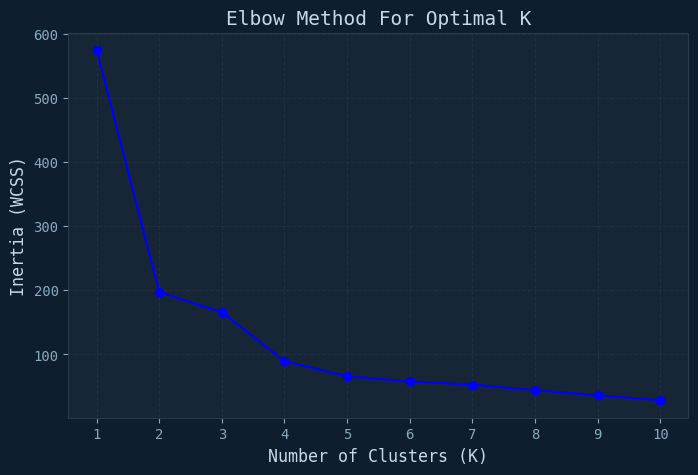

In [83]:
# 1. import
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 2. Calculate inertia for different values of K
inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init='auto' suppresses a common Future Warning in recent sklearn versions
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


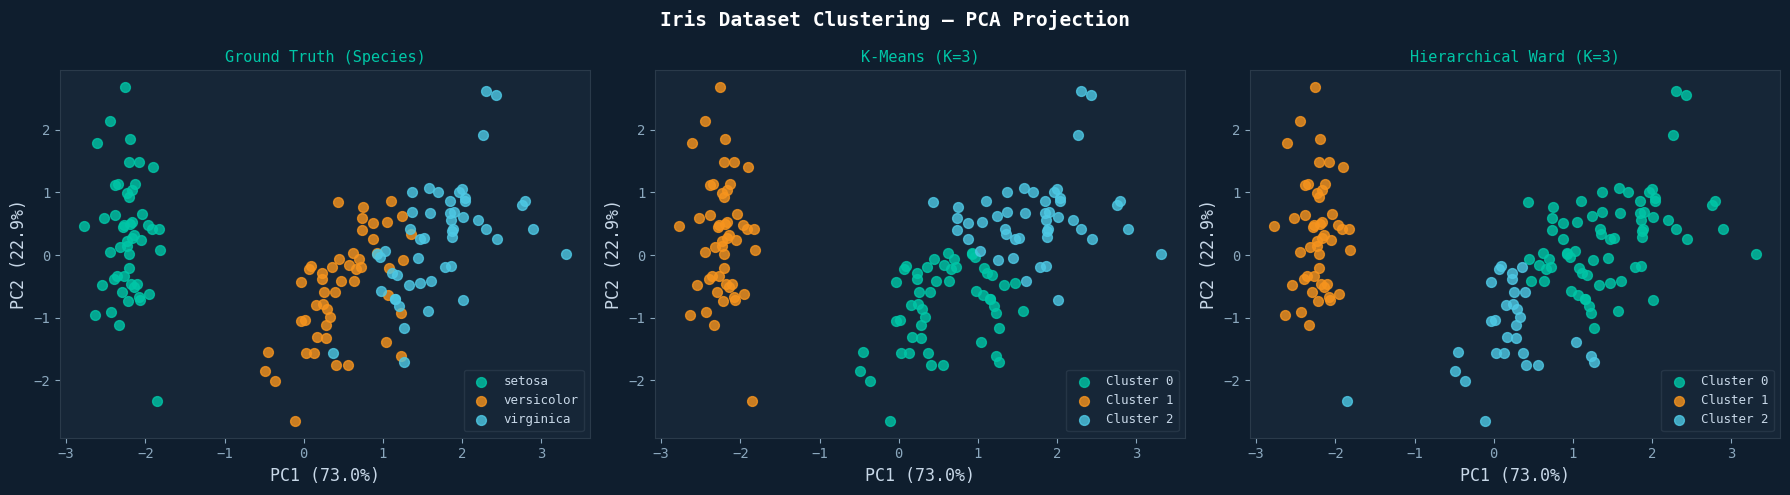

✅  Setosa (bottom-left) is perfectly separated by both algorithms.
    Versicolor and Virginica overlap slightly — even for ground truth.
    ARI > 0.7 means our algorithms recovered ~70-85% of the true structure.


In [ ]:
# ── Visualise Iris Clustering Results ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Iris Dataset Clustering — PCA Projection", fontsize=14, fontweight='bold', color='white')

datasets_vis = [
    (y_iris,    [class_names[y] for y in y_iris], "Ground Truth (Species)"),
    (labels_km, [f"Cluster {k}" for k in labels_km], "K-Means (K=3)"),
    (labels_hc, [f"Cluster {k}" for k in labels_hc], "Hierarchical Ward (K=3)"),
]

for ax, (lbl, lbl_names, title) in zip(axes, datasets_vis):
    unique_lbl = np.unique(lbl)
    for k, clr in zip(unique_lbl, PALETTE):
        mask = lbl == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=clr, s=50, alpha=0.8,
                   label=lbl_names[np.where(mask)[0][0]])
    ax.set_title(title, color=PALETTE[0], fontsize=11)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('iris_clustering.png', dpi=120, bbox_inches='tight')
plt.show()

print("✅  Setosa (bottom-left) is perfectly separated by both algorithms.")
print("    Versicolor and Virginica overlap slightly — even for ground truth.")
print("    ARI > 0.7 means our algorithms recovered ~70-85% of the true structure.")


---
# PART 7 — 🧠 Quiz & Conceptual Review

Answer the following questions. Reveal the answers by running the cell below.

### Questions

**Q1.** What does WCSS stand for, and what is K-Means trying to minimise?

**Q2.** Why do we run K-Means multiple times (n_init > 1)?

**Q3.** If the Elbow curve shows no clear elbow, what alternative metric can you use?

**Q4.** What does a Silhouette Score of 0 mean for a data point?

**Q5.** In hierarchical clustering, what is the difference between Ward and Single linkage?

**Q6.** You have a dataset with 500,000 points. Which algorithm would you prefer: K-Means or Hierarchical? Why?

**Q7.** Your data has ring-shaped clusters (like concentric circles). Both K-Means and Hierarchical fail. What should you use instead?

**Q8.** True or False: AgglomerativeClustering produces the same result every time on the same data.


In [ ]:
# ── Quiz Answers ──────────────────────────────────────────────────────────
answers = {
    "Q1": ("WCSS = Within-Cluster Sum of Squares = Σ Σ ||xᵢ − μₖ||²\n"
           "    K-Means minimises the total squared distance from each point to its centroid."),
    "Q2": ("K-Means converges to a LOCAL minimum — different random starts give different results.\n"
           "    Running n_init times and keeping the best (lowest inertia) reduces this risk."),
    "Q3": ("Use the Silhouette Score — choose K with the highest silhouette value.\n"
           "    Also consider domain knowledge or Calinski-Harabász / Davies-Bouldin."),
    "Q4": ("A silhouette score of 0 means the point is ON THE BOUNDARY between two clusters —\n"
           "    it is equally close to its own cluster and the next nearest cluster."),
    "Q5": ("Ward linkage merges the pair that minimises the INCREASE in total WCSS → compact clusters.\n"
           "    Single linkage merges the pair with minimum distance between any two points → prone to chaining."),
    "Q6": ("K-Means. Time complexity O(n·K·i·d) vs O(n² log n) for Hierarchical.\n"
           "    K-Means scales to millions; Hierarchical would be too slow and memory-intensive."),
    "Q7": ("DBSCAN (Density-Based Spatial Clustering of Applications with Noise)\n"
           "    or HDBSCAN — they detect clusters of arbitrary shape using density."),
    "Q8": ("TRUE — Hierarchical (Agglomerative) Clustering is DETERMINISTIC.\n"
           "    The linkage tree is built from pairwise distances which don't involve randomness."),
}

print("=" * 65)
print("  QUIZ ANSWERS — Clustering Algorithms")
print("=" * 65)
for qnum, (q, a) in enumerate(answers.items(), 1):
    print(f"\n  {q}: {a}")
print("\n" + "=" * 65)
print("  Score yourself: 7-8 = Excellent | 5-6 = Good | <5 = Review again")


  QUIZ ANSWERS — Clustering Algorithms

  Q1: WCSS = Within-Cluster Sum of Squares = Σ Σ ||xᵢ − μₖ||²
    K-Means minimises the total squared distance from each point to its centroid.

  Q2: K-Means converges to a LOCAL minimum — different random starts give different results.
    Running n_init times and keeping the best (lowest inertia) reduces this risk.

  Q3: Use the Silhouette Score — choose K with the highest silhouette value.
    Also consider domain knowledge or Calinski-Harabász / Davies-Bouldin.

  Q4: A silhouette score of 0 means the point is ON THE BOUNDARY between two clusters —
    it is equally close to its own cluster and the next nearest cluster.

  Q5: Ward linkage merges the pair that minimises the INCREASE in total WCSS → compact clusters.
    Single linkage merges the pair with minimum distance between any two points → prone to chaining.

  Q6: K-Means. Time complexity O(n·K·i·d) vs O(n² log n) for Hierarchical.
    K-Means scales to millions; Hierarchical would 

---
# 🎓 Summary & Key Takeaways

## What We Covered

| Topic | Key Points |
|-------|-----------|
| **Clustering Basics** | Unsupervised learning, grouping without labels, real-world applications |
| **K-Means** | Centroid-based, minimises WCSS, k-means++ init, requires K upfront |
| **Elbow Method** | Plot K vs WCSS, find the "knee" in the curve |
| **Silhouette Score** | Internal metric, −1 to +1, validates cluster quality |
| **Hierarchical** | Dendrogram, agglomerative bottom-up, no K needed, Ward linkage recommended |
| **Evaluation** | Silhouette, Calinski-Harabász (↑), Davies-Bouldin (↓) |
| **Comparison** | K-Means = fast+scalable; Hierarchical = flexible hierarchy, slow |

---

## 🧭 Decision Guide

```
How many data points?
├── > 10,000 → K-Means (or MiniBatchKMeans for > 100k)
└── ≤ 10,000 → Either works; use Hierarchical if you want to explore K

Do you know K?
├── Yes → K-Means with Elbow/Silhouette validation
└── No  → Hierarchical (cut dendrogram) or DBSCAN

What shape are the clusters?
├── Convex / Blob-like → K-Means or Hierarchical (Ward)
├── Arbitrary shape    → DBSCAN / HDBSCAN
└── Probabilistic      → Gaussian Mixture Models (GMM)
```

---

## 📚 Further Reading

- Scikit-Learn Clustering: https://scikit-learn.org/stable/modules/clustering.html
- K-Means++ Paper (Arthur & Vassilvitskii, 2007)
- DBSCAN Paper (Ester et al., 1996) — for next steps in density-based clustering

---

## Next Module
➡️ **Dimensionality Reduction** — PCA, t-SNE, UMAP

---

*NIELIT Ropar | AI/ML | Project Engineer*  
*lovnishverma.in*
